In [1]:
import numpy as np
from scipy import optimize
from scipy.constants import mu_0, epsilon_0
from scipy import fftpack
from scipy import sparse
from scipy.special import factorial
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d, CubicSpline,splrep, BSpline
from scipy.sparse import csr_matrix, csc_matrix
import csv
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from IPython.display import display, Math, Latex, Markdown
from scipy.linalg import lu_factor, lu_solve
from scipy import signal
import ipywidgets as widgets
import empymod
import discretize
import  os
import glob
import json
import pandas as pd



In [2]:
import torch
import torch.nn.functional as F
from torch.autograd.functional import jacobian
eps = torch.finfo(torch.float32).eps
print(eps)

1.1920928955078125e-07


In [3]:
from masa_utils import sci_latex
from masa_utils import InducedPolarizationSimulation
from masa_utils import Pelton_res_f, DDR_f, DDC_f
 

In [4]:
plt.style.use('00_figures.mplstyle')
textwidth = 5.60739

In [5]:
# --- helper to render LaTeX labels (robust method) ---
def math_label(tex, width="160px"):
    out = widgets.Output(layout=widgets.Layout(width=width))
    with out:
        display(Math(tex))
    return out
def sci_latex(v, prec=2):
    s = f"{v:.{prec}e}"          # e.g. '3.00e-03'
    mant, exp = s.split('e')
    exp = int(exp)

    if float(mant) == 0:
        return "0"

    if exp in [0, -1]:
        return f"{float(mant)*10**exp:.{prec}f}"
    else:
        return rf"{mant}\cdot 10^{{{exp}}}"


def fmt(v, prec=2, latex=False, wrap=False):
    # blank for None or empty string
    if v is None or v == "":
        return ""

    # if already string → return as-is
    if isinstance(v, str):
        return v

    try:
        s = sci_latex(v, prec=prec)

        if latex:
            if wrap:
                return rf"$${s}$$"   # display math
            else:
                return rf"${s}$"     # inline math
        else:
            return s

    except:
        return ""


In [6]:
rho0= 0.3
res_ref = 0.3
eta= 0.5
expc= 0.6

tau_rho = 1.0e-2

param_text = r"$\rho_0$" + f": {rho0: .2f}, " + r"$\eta$" +f": {eta: .2f}, "  
param_text += r"$\tau_\rho$"+ f": ${fmt(tau_rho, prec=1)}$, " +r"$C$" + f": {expc: .2f}"
mvec_true = np.array([np.log(rho0), eta, np.log(tau_rho), expc])

In [7]:
param_text

'$\\rho_0$:  0.30, $\\eta$:  0.50, $\\tau_\\rho$: $1.0\\cdot 10^{-2}$, $C$:  0.60'

In [8]:
freq_start_log = -1
freq_end_log = 4
freq_step_log = 0.1
nfreq= int((freq_end_log - freq_start_log) / freq_step_log) + 1
freq_1 = np.logspace(freq_start_log, freq_end_log, nfreq)

freq_start_log = 1
freq_end_log = 3
nfreq = int((freq_end_log - freq_start_log) / freq_step_log) + 1
freq_2 = np.logspace(freq_start_log, freq_end_log, nfreq)


In [9]:
IP_model = Pelton_res_f(freq=freq_1)
sim_1 = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")
dobs_1 = np.abs(sim_1.ip_model.f(mvec_true))
sim_1.ip_model.store_parameters(mvec_true)
tau_rho, tau_psi, tau_con = sim_1.ip_model.tau_rho, sim_1.ip_model.tau_psi, sim_1.ip_model.tau_con
IP_model = Pelton_res_f(freq=freq_2)
sim_2 = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")
dobs_2 = np.abs(sim_2.ip_model.f(mvec_true))


In [10]:
texts = [
    r"$\| \rho(\min(f_{\mathrm{band},1})) \|$",
    r"$\| \rho(\max(f_{\mathrm{band},1})) \|$",
    r"$\| \rho(\min(f_{\mathrm{band},2})) \|$",
    r"$\| \rho(\max(f_{\mathrm{band},2})) \|$",
]

texts_xy = []

texts_xy.append(np.r_[freq_1[0], np.abs(dobs_1[0])])
texts_xy.append(np.r_[freq_1[-1], np.abs(dobs_1[-1])])
texts_xy.append(np.r_[freq_2[0], np.abs(dobs_2[0])])
texts_xy.append(np.r_[freq_2[-1], np.abs(dobs_2[-1])])

In [11]:
plt.style.use('00_figures.mplstyle')

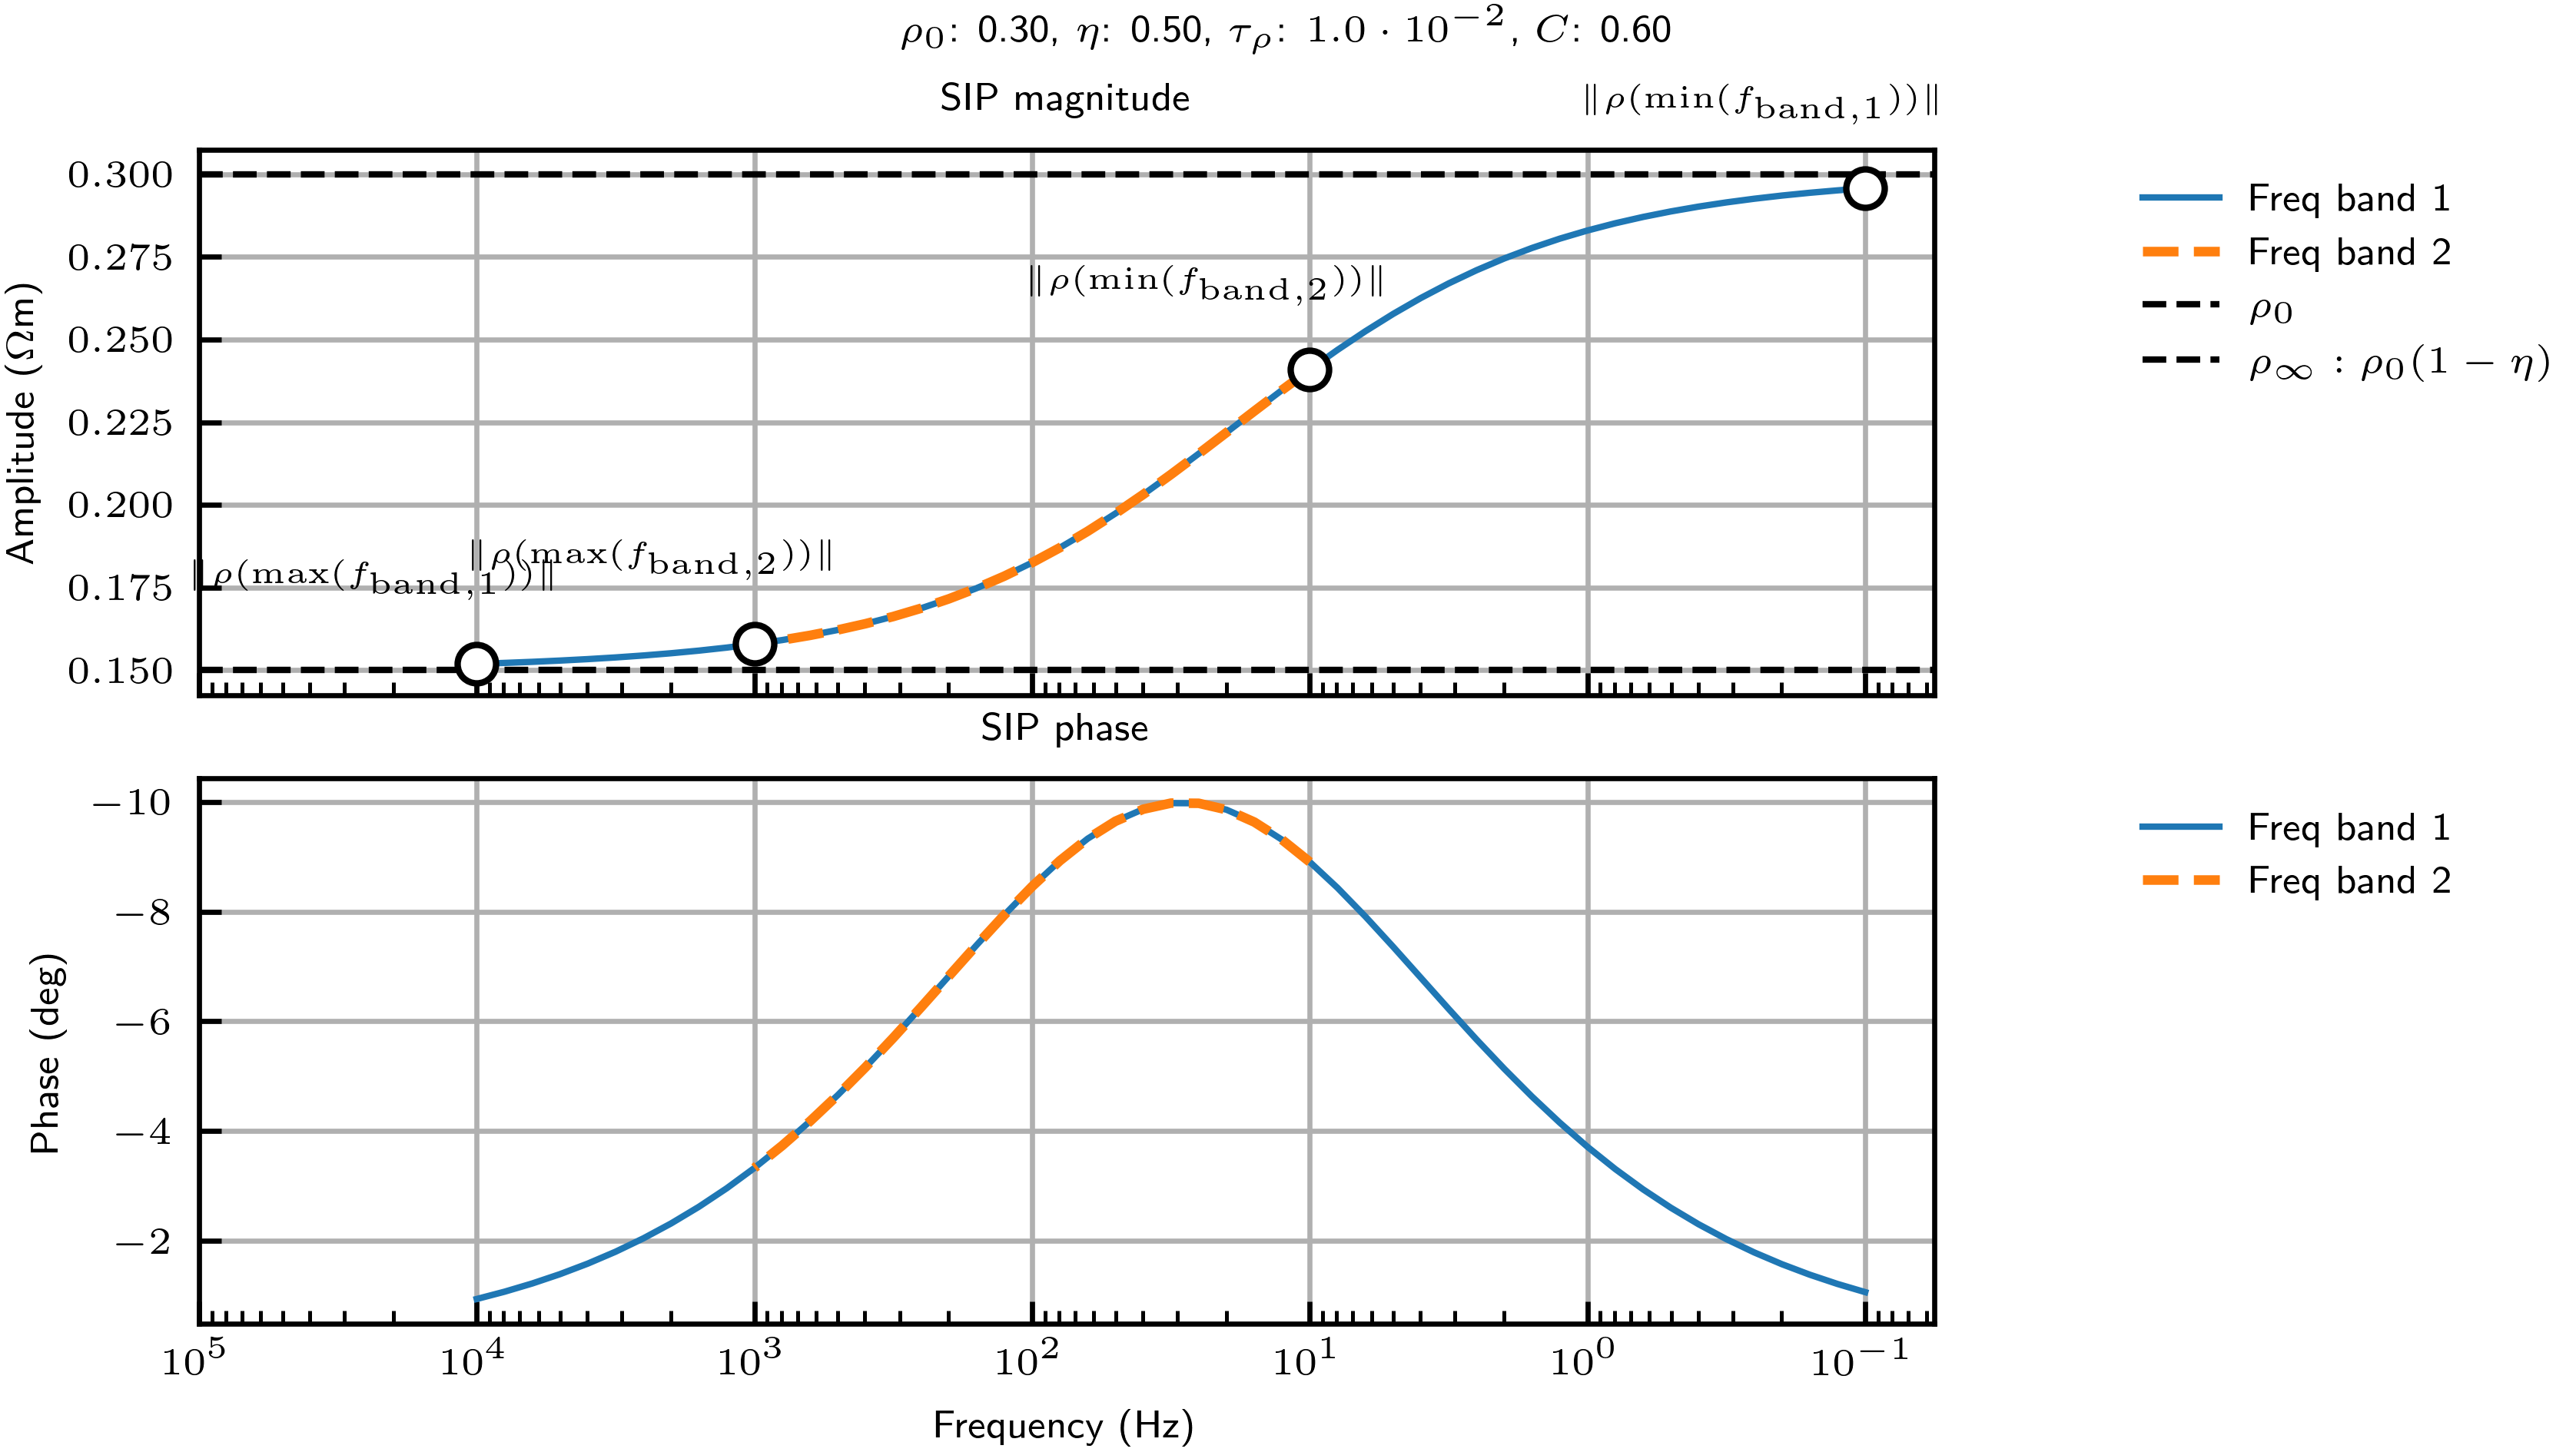

In [12]:
fig, ax = plt.subplots(2, 1, sharex=True,  figsize=(textwidth,3.0))
label = 'Freq band 1'
ax = sim_1.plot_sip_model(mvec_true, ax=ax,
    color='C0', 
    label= label
    )
label = 'Freq band 2'

ax = sim_2.plot_sip_model(mvec_true, ax=ax,
    color='C1', linestyle='--',linewidth=1.5,  
    label=label
    )

ax[0].axhline(y=rho0, color='k', linestyle='--', label=r"$\rho_0$")
ax[0].axhline(y=rho0*(1-eta), color='k', linestyle='--', label=r"$\rho_{\infty}: \rho_0(1-\eta)$ ")
# ax[1].axvline(x=1/2/np.pi/tau_con, color='k', linestyle=':', label=r"$1/2/\pi/\tau_\sigma$")   
# ax[1].axvline(x=1/2/np.pi/tau_psi, color='k', linestyle='-.', label=r"$1/2/\pi/\tau_\phi$")
# ax[1].axvline(x=1/2/np.pi/tau_rho, color='k', linestyle='--' , label=r"$1/2/\pi/\tau_\rho$")

for i, s in enumerate(texts):
    x, y = texts_xy[i]

    # marker at the point
    ax[0].plot(
        x, y,
        marker="o",
        markersize=6,
        markeredgecolor="k",
        markerfacecolor="white",
        zorder=5,
    )

    # annotation
    ax[0].annotate(
        s,
        xy=(x, y),
        xycoords="data",
        textcoords="offset points",
        xytext=(-15, 10),
        ha="center",
        va="bottom",
        fontsize=5,
    )


ax[1].invert_yaxis()
ax[0].invert_xaxis()
ax[0].set_xlim(left=1.e5)
ax[0].tick_params(labelbottom=False)
ax[0].set_xlabel("")
for a in ax:
    a.legend(loc="upper left", bbox_to_anchor=(1.1,1))
    
ax[0].set_title(fr"SIP magnitude")
ax[1].set_title(fr'SIP phase')
fig.suptitle(
    param_text,
    y=1.05
)

plt.savefig("../manuscript/figures/10_SIP_band12.pdf")
plt.savefig('../figures/10_SIP_band12.png')

Prepare Widget

In [35]:

freq_start_log = -1
freq_end_log = 4
freq_step_log = 0.1
nfreq= int((freq_end_log - freq_start_log) / freq_step_log) + 1
freq = np.logspace(freq_start_log, freq_end_log, nfreq)
IP_model = Pelton_res_f(freq=freq, chglim=0)
sim = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")
freq_min, freq_max = freq.min(), freq.max()

In [ ]:
log10rho0min, log10rho0max = -1, 0
rho0min, rho0max = 10**log10rho0min, 10**log10rho0max
etamin, etamax = 0, 1.0
log10taumin, log10taumax = -4, 1
taumin, taumax = 10**log10taumin, 10**log10taumax
cmin, cmax = 0., 1.0
rho0_default, eta_default, tau_default, c_default = 0.3, 0.0,  1e-3, 0.5


In [15]:
def draw_slider(ax, label, val, vmin, vmax, y, logscale=False, fmt=None):
    # normalize value → [0,1]
    if logscale:
        t = (np.log10(val) - np.log10(vmin)) / (np.log10(vmax) - np.log10(vmin))
    else:
        t = (val - vmin) / (vmax - vmin)

    # background line
    ax.plot([0.2, 0.8], [y, y], color='0.7', lw=6, solid_capstyle='round')

    # knob
    x = 0.2 + 0.6 * t
    ax.plot(x, y, 'o', color='white', markeredgecolor='black', markersize=10)

    # label + value
    ax.text(0.05, y, label, va='center', fontsize=14)
    if fmt is not None:
        ax.text(0.85, y, f"${fmt(val)}$", va='center', fontsize=14)
    else:
        ax.text(0.85, y, f"{val:.3g}", va='center', fontsize=14)



In [ ]:
#  Widget for the main function
def plot_pelton_widget(
         rho0=None, eta=None, tau=None, c=None):
    # Clear the current output to avoid duplicate figures
    
    # Create the plot
    fig, ax = plt.subplots(3, 1, figsize=(11, 6), dpi=300)
    axsip = [ax[0], ax[1]]
    axui = ax[2]

    m = np.r_[np.log(rho0), eta, np.log(tau), c]
    ax = sim.plot_sip_model(m, ax=axsip, color='C0', label="")
    sim.ip_model.store_parameters(m)
    tau_rho, tau_psi, tau_con = sim.ip_model.tau_rho, sim.ip_model.tau_psi, sim.ip_model.tau_con
    axsip[0].set_xlim(left=freq_max, right=freq_min)
    axsip[0].axhline(y=rho0, color='k', linestyle='--', label=r"$\rho_0$")
    axsip[0].axhline(y=rho0*(1-eta), color='k', linestyle='--', label=r"$\rho_{\infty}$")
    axsip[1].set_xlim(left=freq_max, right=freq_min)
    axsip[1].axvline(x=1/2/np.pi/tau_con, color='k', linestyle='-.', label=r"$1/2/\pi/\tau_\sigma$")   
    axsip[1].axvline(x=1/2/np.pi/tau_psi, color='k', linestyle='--', label=r"$1/2/\pi/\tau_\psi$")
    axsip[1].axvline(x=1/2/np.pi/tau_rho, color='k', linestyle=':' , label=r"$1/2/\pi/\tau_\rho$")
    axsip[1].legend()
    axsip[0].set_ylim([0  ,1.1])
    axsip[0].set_xlabel("")
    axsip[0].tick_params(
            axis='x',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            bottom=True,      # ticks along the bottom edge are off
            top=False,         # ticks along the top edge are off
            labelbottom=False) # labels along the bottom edge are off
    axsip[1].set_ylim([1,-15])
    for a in axsip:
        a.grid()

    axui.axis("off")

    draw_slider(axui, r"$\rho_0\,(\Omega\,\mathrm{m})$", rho0, rho0min, rho0max, 0.75)
    draw_slider(axui, r"$\eta$", eta, etamin, etamax, 0.5)
    draw_slider(axui, r"$\tau_{\rho}\,(\mathrm{s})$", tau, taumin, taumax, 0.25, logscale=True, fmt=fmt)
    draw_slider(axui, r"$C$", c, cmin, cmax, 0.0)

    axui.set_xlim(0, 1)
    axui.set_ylim(-0.1, 1)

    fig.tight_layout()
    return fig

In [ ]:

# --- sliders ---
rho0_slider = widgets.FloatLogSlider(
    base=10, min=log10rho0min, max=log10rho0max, step=0.01, value=rho0_default, description=""
)

eta_slider = widgets.FloatSlider(
    min=etamin, max=etamax, step=0.01, value=eta_default, description=""
)

tau_slider = widgets.FloatLogSlider(
    base=10, min=log10taumin, max=log10taumax, step=0.01, value=tau_default, description=""
)

c_slider = widgets.FloatSlider(
    min=cmin, max=cmax, step=0.01, value=c_default, description=""
)


In [ ]:

# --- labeled rows ---
rho0_row = widgets.HBox([
    math_label(r"\rho_0\,(\Omega\,\mathrm{m})"),
    rho0_slider
])

eta_row = widgets.HBox([
    math_label(r"\eta"),
    eta_slider
])

tau_row = widgets.HBox([
    math_label(r"\tau_{\rho}\,(\mathrm{s})"),
    tau_slider
])

c_row = widgets.HBox([
    math_label(r"c"),
    c_slider
])


In [ ]:




# --- controls layout ---
controls = widgets.VBox([rho0_row, eta_row, tau_row, c_row])


# --- connect UI to function (NO duplicate sliders) ---
out = widgets.interactive_output(
    plot_pelton_widget,
    {
        "rho0": rho0_slider,
        "eta": eta_slider,
        "tau": tau_slider,
        "c": c_slider,
    },
)
plt.tight_layout()
# --- display everything ---
display(controls, out)

Output()

<Figure size 640x480 with 0 Axes>

In [ ]:
# -----------------------------
# 2) Define your base values and sweep ranges
# -----------------------------
# Use your defaults here:
rho0_base = rho0_default
eta_base  = eta_default
tau_base  = tau_default
c_base    = c_default

# Choose sweep ranges (edit these!)
rho0_vals_1 = np.linspace(start=0.1, stop=1.0, num=46)
eta_vals  = np.linspace(0, 0.4, 41)
rho0_vals_2 = np.r_[np.linspace(start=1.0, stop=0.5, num=26),
                     np.linspace(start=0.5, stop=1.0, num=26)]
tau_vals  = np.r_[np.logspace(start=-3, stop=1.0,base=10, num=81),
                  np.logspace(start=1.0, stop=-2,base=10, num=61)]
c_vals    = np.r_[np.linspace(0.5, 1.0, 26), 
                  np.linspace(1.0, 0.2,41)]

# Optional: keep your freq limits if you have them


# -----------------------------
# 3) Build a list of parameter states (ρ0 then η then τ then c)
# -----------------------------
states = []

# sweep rho0
for r in rho0_vals_1:
    states.append((r, eta_base, tau_base, c_base))

# sweep eta
for e in eta_vals:
    states.append((rho0_vals_1[-1], e, tau_base, c_base))

for r in rho0_vals_2:
    states.append((r, eta_vals[-1], tau_base, c_base))

# sweep tau_rho
for t in tau_vals:
    states.append((rho0_vals_2[-1], eta_vals[-1], t, c_base))

# sweep c
for cc in c_vals:
    states.append((rho0_vals_2[-1], eta_vals[-1], tau_vals[-1], cc))



Saved: 10_sip_sweep.mp4


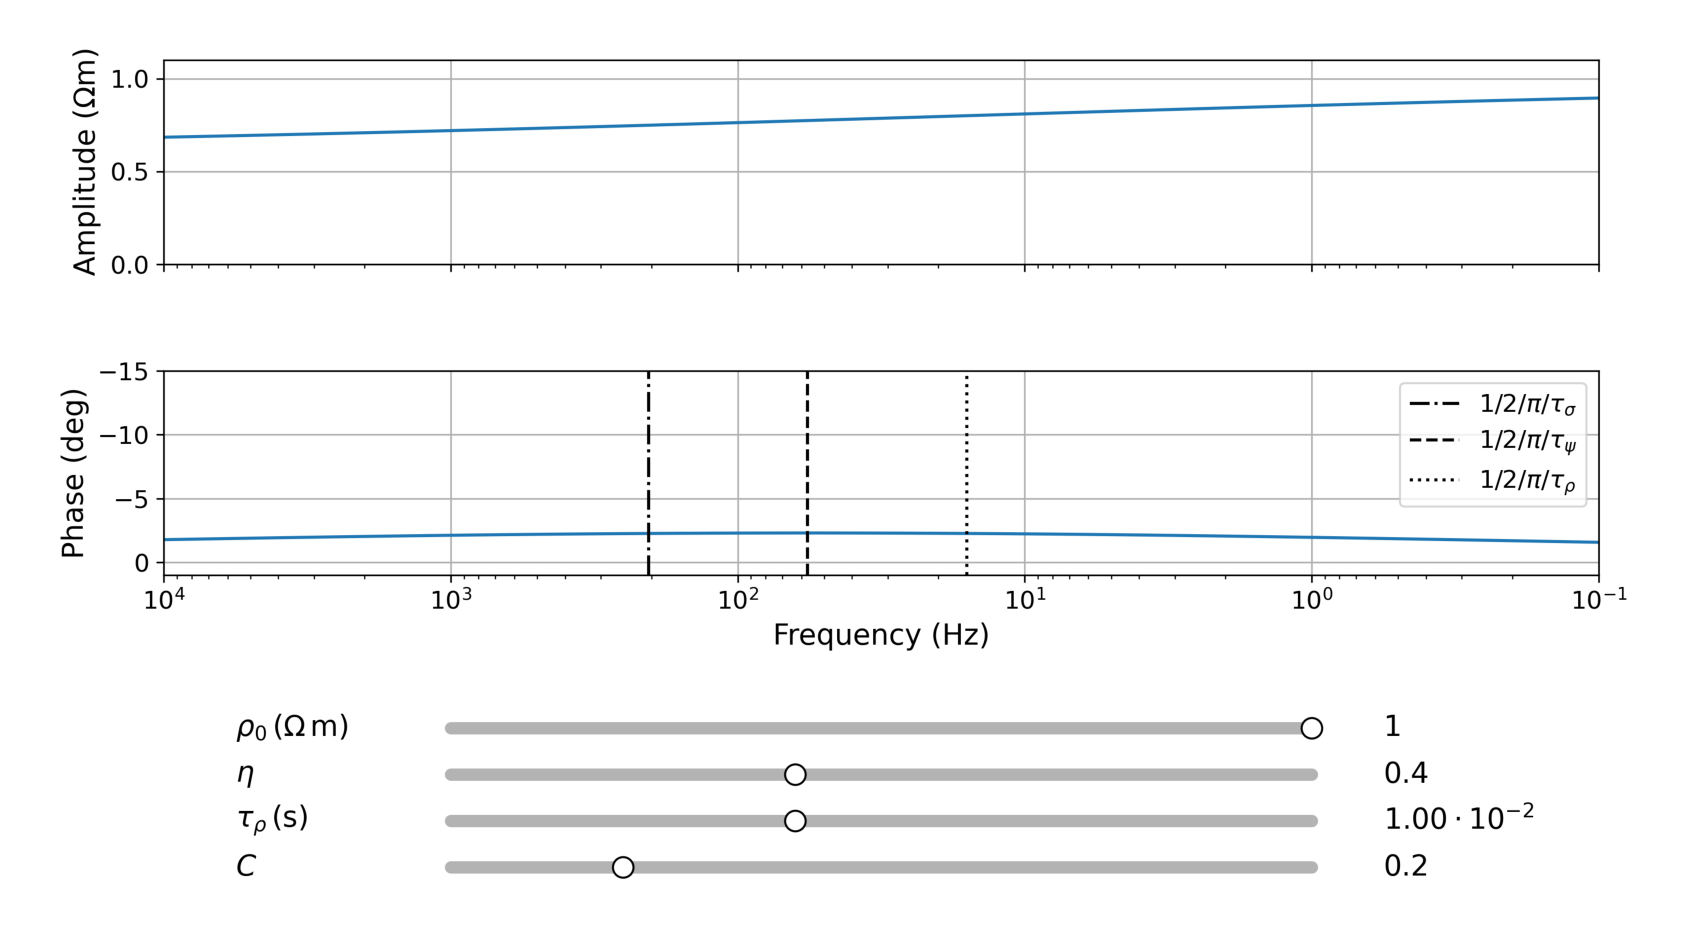

In [ ]:
# -----------------------------
# settings
# -----------------------------
out_mp4 = "10_sip_sweep.mp4"
fps = 15
tmp_dir = "10"

os.makedirs(tmp_dir, exist_ok=True)

# (optional) clean old images first
for f in glob.glob(os.path.join(tmp_dir, "*.png")):
    os.remove(f)

# -----------------------------
# frame generator
# -----------------------------
def make_frame(i):
    rho0, eta, tau, c = states[i]
    fig = plot_pelton_widget(rho0, eta, tau, c)
    return fig

# -----------------------------
# video writer
# -----------------------------
dpi = 300
fig_writer, ax_writer = plt.subplots(figsize=(7,6), dpi=dpi)

writer = animation.FFMpegWriter(fps=fps, metadata={"artist": "matplotlib"})

with writer.saving(fig_writer, out_mp4, dpi=dpi):
    for i in range(len(states)):
        fig_i = make_frame(i)

        # save temp image
        fname = os.path.join(tmp_dir, f"10_sip_frame_{i:04d}.png")
        fig_i.savefig(fname, dpi=dpi)

        # read image
        img = plt.imread(fname)

        # draw into writer figure
        ax_writer.clear()
        ax_writer.imshow(img)
        ax_writer.axis("off")

        writer.grab_frame()

        # VERY IMPORTANT
        plt.close(fig_i)

print("Saved:", out_mp4)



In [23]:
# -----------------------------
# cleanup
# -----------------------------
for f in glob.glob(os.path.join(tmp_dir, "10_sip_frame_*.png")):
    os.remove(f)

print("Temporary images deleted.")

Temporary images deleted.
